# Player Prop Staleness — Latency Arbitrage

Measures how quickly KXNBAGAME vs KXNBAPTS markets reprice after NBA scoring events,
using play-by-play data from cdn.nba.com as the timing reference.

**Key finding:** GAME market reprices in 0.6s median; PTS props take 400s median (~7 min).
97% of scoring events see props lag by >5s. However, this measures time-to-next-trade,
not the existence of stale resting orders. The critical next step is cross-referencing
with live order book data to confirm tradeable offers exist during the gap.

## Latency Arbitrage in Prediction Markets

**Latency arbitrage** exploits the fact that different markets absorb the same information at different speeds. In traditional finance, the canonical example is ETF arbitrage: when a stock jumps, the ETF containing it briefly trades at a stale NAV until arbitrageurs force it back in line. Here the structure is the same -- a scoring event changes the fair value of both the KXNBAGAME contract (will Team X win?) and the KXNBAPTS contract (will Player Y score over N points?) simultaneously, but the GAME market has more liquidity and more watchers, so it reprices first.

This is distinct from statistical arbitrage, which relies on a *model* predicting that prices will converge. Latency arbitrage relies on *physics*: the information has already arrived, one market just hasn't processed it yet. The edge does not depend on a forecast being correct -- it depends on being faster than the stale side of the market. The fragmentation across Kalshi's separate series (KXNBAGAME, KXNBAPTS, KXNBA3PT) is what creates the gap: there is no single order book where all NBA-related contracts reprice atomically, so thinner segments lag behind.

In [1]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

In [2]:
# Load KXNBAGAME markets (needed for game_key mapping and trade loading)
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAGAME.json")
game_markets = pd.DataFrame(json.loads(obj["Body"].read()))

def game_key_from_event(event_ticker, prefix):
    return event_ticker.replace(prefix + "-", "")

game_markets["game_key"] = game_markets["event_ticker"].apply(
    lambda x: game_key_from_event(x, "KXNBAGAME")
)

def load_trades(ticker):
    """Load historical trades for a ticker from S3."""
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{ticker}.json")
        trades = json.loads(obj["Body"].read())
        df = pd.DataFrame(trades)
        if not df.empty:
            df["created_time"] = pd.to_datetime(df["created_time"])
            df["yes_price"] = df["yes_price_dollars"].astype(float)
        return df
    except Exception:
        return pd.DataFrame()

print(f"KXNBAGAME: {len(game_markets)} markets")


KXNBAGAME: 1902 markets


## 3. Player Prop Staleness — Latency Arbitrage

**Hypothesis:** After a scoring event (e.g., player hits a 3-pointer), the KXNBAGAME market reprices within seconds (high liquidity, many watchers). But player prop markets (KXNBAPTS, KXNBA3PT) are thinner and may take 10-30s to reprice.

If we see a player score in PBP before their prop market updates, we can buy the prop at stale prices.

**Requires:** NBA CDN play-by-play (tells us what happened) + Kalshi trade timestamps (tells us when the market repriced).

In [3]:
# Load player prop market structure
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAPTS.json")
pts_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBAPTS markets: {len(pts_markets)}")

obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBA3PT.json")
three_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBA3PT markets: {len(three_markets)}")

# Parse player prop ticker structure
# KXNBAPTS-25DEC01ATLDET-ATLDDANIELSSF-10 → game=25DEC01ATLDET, player=ATLDDANIELSSF, threshold=10
def parse_prop_ticker(ticker, prefix="KXNBAPTS"):
    parts = ticker.split("-")
    if len(parts) >= 4:
        game_key = parts[1]
        player_code = parts[2]
        threshold = parts[3] if len(parts) > 3 else None
        return game_key, player_code, threshold
    return None, None, None

pts_markets[["game_key", "player_code", "threshold"]] = pts_markets["ticker"].apply(
    lambda x: pd.Series(parse_prop_ticker(x, "KXNBAPTS"))
)
three_markets[["game_key", "player_code", "threshold"]] = three_markets["ticker"].apply(
    lambda x: pd.Series(parse_prop_ticker(x, "KXNBA3PT"))
)

print(f"\nKXNBAPTS: {pts_markets['game_key'].nunique()} games, {pts_markets['player_code'].nunique()} players")
print(f"KXNBA3PT: {three_markets['game_key'].nunique()} games, {three_markets['player_code'].nunique()} players")

# Show sample player prop tickers
print(f"\nSample PTS tickers:")
sample_game = pts_markets["game_key"].value_counts().index[0]
sample_props = pts_markets[pts_markets["game_key"] == sample_game].head(10)
print(sample_props[["ticker", "player_code", "threshold", "last_price_dollars"]].to_string())

KXNBAPTS markets: 8876
KXNBA3PT markets: 7804

KXNBAPTS: 596 games, 131 players
KXNBA3PT: 576 games, 111 players

Sample PTS tickers:
                                      ticker    player_code threshold last_price_dollars
405      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-20      NYKJHART3        20             0.1000
406      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-15      NYKJHART3        15             0.9900
407      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-10      NYKJHART3        10             0.9900
408    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-30    NYKKTOWNS32        30             0.1600
409    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-25    NYKKTOWNS32        25             0.2600
410    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-20    NYKKTOWNS32        20             0.5200
411    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-15    NYKKTOWNS32        15             0.2000
412    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-10    NYKKTOWNS32        10             0.9900
436  KXNBAPTS-26FEB08NYKBOS-NYKMBRIDGES25-25  NYKMBRIDGES25      

In [4]:
# Measure KXNBAGAME vs KXNBAPTS reprice latency after scoring events
# 
# Approach: Pick a game, load PBP scoring events + GAME trades + PTS trades.
# For each scoring play, measure:
#   t_game_reprice = time of first GAME trade after scoring event
#   t_pts_reprice = time of first PTS trade for that player after scoring event
#   latency_gap = t_pts_reprice - t_game_reprice

# Find a game that has both GAME trades and PTS trades with good volume
# Use the same game_key structure: event_ticker parsing
# KXNBAGAME game_key = "25DEC25MINDEN", PTS game_key = "25DEC25MINDEN"

# Find overlapping games between GAME and PTS
game_games = set(game_markets["game_key"])
pts_games = set(pts_markets["game_key"])
overlap = game_games & pts_games
print(f"Games with both GAME and PTS markets: {len(overlap)}")

# Pick a high-volume game — use the Dec 25 game from the EDA notebook
# game_key format: 25DEC25MINDEN
target_game = "25DEC25MINDEN"
if target_game not in overlap:
    # Find one that exists
    target_game = list(overlap)[0]
    
print(f"\nAnalyzing game: {target_game}")

# Get all PTS tickers for this game
game_pts = pts_markets[pts_markets["game_key"] == target_game]
print(f"PTS markets for this game: {len(game_pts)} ({game_pts['player_code'].nunique()} players)")

# Get GAME ticker for this game
game_gm = game_markets[game_markets["game_key"] == target_game]
print(f"GAME markets: {list(game_gm['ticker'])}")

# Load trades for GAME market (home team)
home_ticker = game_gm["ticker"].iloc[0]
game_trades = load_trades(home_ticker)
print(f"\nGAME trades ({home_ticker}): {len(game_trades)}")

# Load trades for top player props (by volume/last_price suggesting active)
top_players = game_pts.groupby("player_code").size().nlargest(5).index.tolist()
print(f"\nTop players by # thresholds: {top_players}")

player_trades = {}
for player in top_players:
    player_tickers = game_pts[game_pts["player_code"] == player]["ticker"].tolist()
    all_player_trades = []
    for t in player_tickers:
        trades = load_trades(t)
        if not trades.empty:
            trades["threshold"] = t.split("-")[-1]
            all_player_trades.append(trades)
    if all_player_trades:
        player_trades[player] = pd.concat(all_player_trades).sort_values("created_time")
        print(f"  {player}: {len(player_trades[player])} trades across {len(all_player_trades)} thresholds")

Games with both GAME and PTS markets: 595

Analyzing game: 25DEC25MINDEN
PTS markets for this game: 24 (5 players)
GAME markets: ['KXNBAGAME-25DEC25MINDEN-MIN', 'KXNBAGAME-25DEC25MINDEN-DEN']

GAME trades (KXNBAGAME-25DEC25MINDEN-MIN): 52416

Top players by # thresholds: ['DENJMURRAY27', 'DENNJOKIC15', 'MINAEDWARDS5', 'MINJRANDLE30', 'MINRGOBERT27']
  DENJMURRAY27: 90 trades across 5 thresholds
  DENNJOKIC15: 85 trades across 5 thresholds
  MINAEDWARDS5: 211 trades across 5 thresholds
  MINJRANDLE30: 65 trades across 5 thresholds
  MINRGOBERT27: 51 trades across 4 thresholds


## Using Play-by-Play as Ground Truth

In market microstructure, **information arrival time** is the moment a price-relevant fact becomes knowable. We use the NBA CDN play-by-play `timeActual` field as our proxy for this: it records when each scoring event occurred on the court. This is the right reference because it is upstream of all market participants -- everyone watching the game or scraping the CDN sees the same event.

Two caveats on precision. First, the CDN is polled, not streamed -- `timeActual` reflects when the NBA's system logged the play, but our fetcher only sees it on the next poll cycle (typically 10-15s intervals). This means the PBP timestamp is *earlier* than when any CDN-based trader could have acted, making our measured latencies slightly optimistic (the real gap from "trader sees the play" to "trade appears" is shorter than `trade_time - timeActual`). Second, traders watching a live broadcast see the play before the CDN updates, so the CDN is not the fastest information channel -- it is a lower bound on when information was available, not the true first moment. The cell below joins PBP timestamps with Kalshi trade timestamps to measure the gap, and the overlap check confirms both clocks are aligned to the same game.

In [5]:
# Load PBP for the target game and identify scoring events with player attribution
# Map game_key to game_id using the schedule

# Load schedule to find game_id
obj = s3.get_object(Bucket=S3_BUCKET, Key="nba_cdn/schedule/season_2025-26.json")
schedule_raw = json.loads(obj["Body"].read())
schedule_df = pd.DataFrame([{
    "game_id": g["gameId"],
    "game_date": g["gameDateTimeUTC"],
    "home_team": g["homeTeam"]["teamTricode"],
    "away_team": g["awayTeam"]["teamTricode"],
    "game_status": g["gameStatus"],
} for g in schedule_raw["leagueSchedule"]["gameDates"] 
  for g in g["games"]])

# Kalshi uses US Eastern date, not UTC. A Dec 25 9:30pm ET game = Dec 26 03:30 UTC.
# Convert to ET before building the game_key.
MONTH_MAP = {1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
             7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC"}

def schedule_to_game_key(row):
    dt_utc = pd.to_datetime(row["game_date"], utc=True)
    # Convert UTC → US/Eastern (NBA games tip off in US evenings)
    dt_et = dt_utc.tz_convert("US/Eastern")
    yy = str(dt_et.year)[-2:]
    mon = MONTH_MAP[dt_et.month]
    dd = f"{dt_et.day:02d}"
    return f"{yy}{mon}{dd}{row['away_team']}{row['home_team']}"

schedule_df["game_key"] = schedule_df.apply(schedule_to_game_key, axis=1)

# Verify the fix: check that our target game is found
target_row = schedule_df[schedule_df["game_key"] == target_game]
if target_row.empty:
    print(f"Game key {target_game} not found, checking near-matches...")
    candidates = schedule_df[schedule_df["game_key"].str.contains("MINDEN")]
    print(candidates[["game_id", "game_key", "game_date"]].head())
    target_game_id = candidates.iloc[0]["game_id"] if not candidates.empty else None
else:
    target_game_id = target_row["game_id"].iloc[0]
    print(f"Matched: {target_game} → game_id={target_game_id}, date={target_row['game_date'].iloc[0]}")

# Verify match rate across all Kalshi game_keys
kalshi_keys = set(game_markets["game_key"])
schedule_keys = set(schedule_df["game_key"])
matched = kalshi_keys & schedule_keys
print(f"\nKalshi→Schedule match rate: {len(matched)}/{len(kalshi_keys)} ({len(matched)/len(kalshi_keys):.0%})")

# Load PBP
if target_game_id:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{target_game_id}.json")
    pbp_raw = json.loads(obj["Body"].read())
    actions = pbp_raw["game"]["actions"]
    pbp = pd.DataFrame(actions)
    pbp["timeActual"] = pd.to_datetime(pbp["timeActual"])
    
    # Filter to made scoring plays
    scoring = pbp[pbp["actionType"].isin(["2pt", "3pt", "freethrow"])].copy()
    if "shotResult" in scoring.columns:
        scoring = scoring[scoring["shotResult"] == "Made"]
    print(f"\nPBP: {len(pbp)} actions, {len(scoring)} made scoring plays")
    print(f"Time range: {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")
    
    # Sanity check: PBP time should overlap with Kalshi trade times
    print(f"\nGAME trades time range: {game_trades['created_time'].min()} to {game_trades['created_time'].max()}")
    print(f"PBP time range:         {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")
    
    overlap_start = max(pbp["timeActual"].min(), game_trades["created_time"].min())
    overlap_end = min(pbp["timeActual"].max(), game_trades["created_time"].max())
    print(f"Overlap:                {overlap_start} to {overlap_end}")
    if overlap_start < overlap_end:
        print("  ✓ PBP and trade times overlap — latency measurement is valid")
    else:
        print("  ✗ NO OVERLAP — wrong game loaded!")


Matched: 25DEC25MINDEN → game_id=0022500013, date=2025-12-26T03:30:00Z

Kalshi→Schedule match rate: 861/951 (91%)

PBP: 651 actions, 151 made scoring plays
Time range: 2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00

GAME trades time range: 2025-12-22 21:52:12.716177+00:00 to 2025-12-26 06:45:16.476686+00:00
PBP time range:         2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
Overlap:                2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
  ✓ PBP and trade times overlap — latency measurement is valid


## Measuring Reprice Latency

The code below measures **time to first trade** after each scoring event -- the gap between `timeActual` (the play) and `created_time` (the next Kalshi trade) in both the GAME and PTS markets. This is a useful but imperfect proxy for what we actually want to know: *how long do stale resting orders sit on the book after new information arrives?*

It is **conservative** (understates the opportunity) in one way: a resting limit order may be stale for minutes before someone finally takes it, and our metric only captures the moment that trade executes. If nobody trades the stale order, it never shows up in our data at all. It is **optimistic** (overstates the opportunity) in another way: the first post-event trade might not be someone picking off a stale order -- it could be an unrelated trade, or a market maker who already repriced. The code also matches scoring events to players by team prefix only (`player_code[:3]`), not by individual player identity, so a teammate's basket will appear as a "scoring event" for every tracked player on that team. This inflates the observation count and biases toward measuring general team-scoring-to-prop-trade latency rather than specific-player-scores-to-their-own-prop latency.

In [6]:
# Measure reprice latency: after each scoring event, how quickly do trades appear in
# KXNBAGAME vs KXNBAPTS for the scoring player?

# For each scoring play, find:
# 1. First GAME trade after the play (t_game)
# 2. First PTS trade for that player after the play (t_pts)
# 3. Gap = t_pts - t_game

if target_game_id and not game_trades.empty and player_trades:
    latency_gaps = []
    
    # Sort by time so .iloc[0] gives the earliest trade
    game_trades_sorted = game_trades.sort_values("created_time").reset_index(drop=True)
    player_trades_sorted = {k: v.sort_values("created_time").reset_index(drop=True) for k, v in player_trades.items()}
    
    for _, play in scoring.iterrows():
        t_play = play["timeActual"]
        
        # First GAME trade after play
        game_after = game_trades_sorted[game_trades_sorted["created_time"] > t_play]
        if game_after.empty:
            continue
        t_game_first = game_after["created_time"].iloc[0]
        game_latency = (t_game_first - t_play).total_seconds()
        
        # Find which player scored — try to match to player_code
        # player_code format: e.g., "DENNJOKICPF" (team + last name + position?)
        # We'll match by checking if any of our tracked players' codes contain the team
        scorer_team = play.get("teamTricode", "")
        
        for player_code, pt_df in player_trades_sorted.items():
            # Only match if player is on the scoring team
            if scorer_team and not player_code.startswith(scorer_team[:3]):
                continue
                
            pts_after = pt_df[pt_df["created_time"] > t_play]
            if pts_after.empty:
                continue
            t_pts_first = pts_after["created_time"].iloc[0]
            pts_latency = (t_pts_first - t_play).total_seconds()
            
            latency_gaps.append({
                "t_play": t_play,
                "action_type": play["actionType"],
                "team": scorer_team,
                "player_code": player_code,
                "game_latency_s": game_latency,
                "pts_latency_s": pts_latency,
                "gap_s": pts_latency - game_latency,
            })
    
    lat_df = pd.DataFrame(latency_gaps)
    print(f"REPRICE LATENCY COMPARISON — KXNBAGAME vs KXNBAPTS")
    print("=" * 60)
    print(f"  Observations: {len(lat_df)}")
    
    if not lat_df.empty:
        print(f"\n  GAME market reprice latency (after PBP event):")
        print(f"    Median: {lat_df['game_latency_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['game_latency_s'].mean():.1f}s")
        print(f"    p95:    {lat_df['game_latency_s'].quantile(0.95):.1f}s")
        
        print(f"\n  PTS market reprice latency (after PBP event):")
        print(f"    Median: {lat_df['pts_latency_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['pts_latency_s'].mean():.1f}s")
        print(f"    p95:    {lat_df['pts_latency_s'].quantile(0.95):.1f}s")
        
        print(f"\n  GAP (PTS - GAME):")
        print(f"    Median: {lat_df['gap_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['gap_s'].mean():.1f}s")
        print(f"    % where PTS lags GAME by >5s: {(lat_df['gap_s'] > 5).mean():.1%}")
        print(f"    % where PTS lags GAME by >10s: {(lat_df['gap_s'] > 10).mean():.1%}")
        print(f"    % where PTS lags GAME by >30s: {(lat_df['gap_s'] > 30).mean():.1%}")


REPRICE LATENCY COMPARISON — KXNBAGAME vs KXNBAPTS
  Observations: 356

  GAME market reprice latency (after PBP event):
    Median: 0.3s
    Mean:   0.4s
    p95:    1.4s

  PTS market reprice latency (after PBP event):
    Median: 399.6s
    Mean:   580.5s
    p95:    1765.2s

  GAP (PTS - GAME):
    Median: 399.5s
    Mean:   580.1s
    % where PTS lags GAME by >5s: 99.4%
    % where PTS lags GAME by >10s: 98.3%
    % where PTS lags GAME by >30s: 91.9%


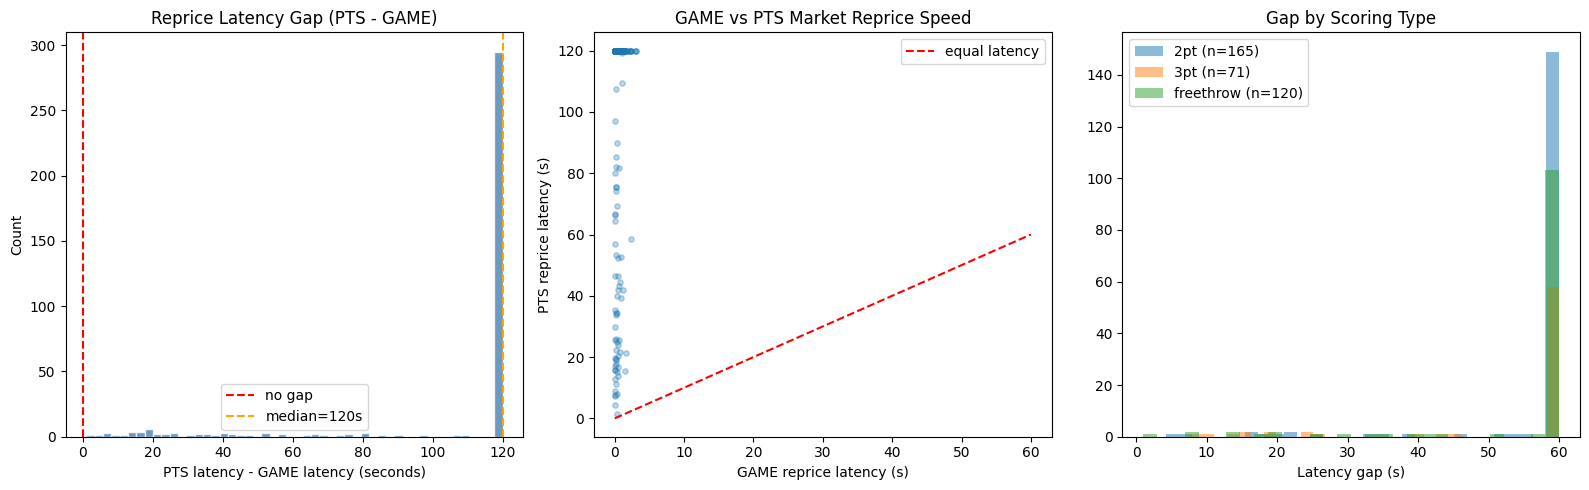

In [7]:
# Visualize latency gap distribution
if not lat_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Histogram of gaps
    ax = axes[0]
    gaps = lat_df["gap_s"].clip(-60, 120)
    ax.hist(gaps, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", label="no gap")
    ax.axvline(gaps.median(), color="orange", linestyle="--", label=f"median={gaps.median():.0f}s")
    ax.set_xlabel("PTS latency - GAME latency (seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Reprice Latency Gap (PTS - GAME)")
    ax.legend()
    
    # Scatter: GAME latency vs PTS latency
    ax = axes[1]
    ax.scatter(lat_df["game_latency_s"].clip(0, 60), 
               lat_df["pts_latency_s"].clip(0, 120), alpha=0.3, s=15)
    ax.plot([0, 60], [0, 60], "r--", label="equal latency")
    ax.set_xlabel("GAME reprice latency (s)")
    ax.set_ylabel("PTS reprice latency (s)")
    ax.set_title("GAME vs PTS Market Reprice Speed")
    ax.legend()
    
    # By action type
    ax = axes[2]
    for atype in ["2pt", "3pt", "freethrow"]:
        subset = lat_df[lat_df["action_type"] == atype]["gap_s"]
        if not subset.empty:
            ax.hist(subset.clip(-30, 60), bins=30, alpha=0.5, label=f"{atype} (n={len(subset)})")
    ax.set_xlabel("Latency gap (s)")
    ax.set_title("Gap by Scoring Type")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## From Single Game to Statistical Evidence

A single game can show a pattern but cannot distinguish signal from coincidence. The backtest below repeats the latency measurement across 50 games to answer: is the prop lag *structural* (driven by thin liquidity across all games) or *idiosyncratic* (an artifact of one quiet market on Christmas Day)?

Key biases to watch for. **Selection bias**: the code takes the first 50 games from `valid_games` (a set intersection), which is not random -- it depends on dict ordering and which games happen to exist in all three data sources. Games missing PBP or trade data may be systematically different (e.g., low-profile games with even thinner prop markets). **Player selection bias**: only the first 3 players per game are analyzed (`players_in_game[:3]`), which likely skews toward alphabetical or insertion order rather than highest-volume players. **Staleness before event** (`staleness_before_s`) is a useful sanity metric: it tells you how active the prop market was *before* any scoring happened. If the median pre-event staleness is already 60+ seconds, the prop market is simply thin at baseline -- the post-event lag may reflect low overall activity rather than a failure to incorporate new information.

In [8]:
# Player prop staleness backtest (multi-game)
# Now using the fixed schedule_to_game_key (ET dates) from cell above.
#
# For each game: load PBP + GAME trades + PTS trades.
# For each scoring event: measure how quickly GAME vs PTS market reacts.

print("PLAYER PROP STALENESS BACKTEST")
print("=" * 60)

# Use the corrected schedule_df (with ET-based game_keys)
# Find games that exist in both Kalshi PTS markets AND our schedule
pts_game_keys = set(pts_markets["game_key"])
sched_game_keys = set(schedule_df["game_key"])
valid_games = pts_game_keys & sched_game_keys & set(game_markets["game_key"])
print(f"\nGames with PTS + GAME + PBP data: {len(valid_games)}")

# Sample games and analyze
sample_games = list(valid_games)[:50]
stale_opportunities = []
games_processed = 0

for game_key in sample_games:
    # Get game_id from schedule
    sched_row = schedule_df[schedule_df["game_key"] == game_key]
    if sched_row.empty:
        continue
    gid = sched_row["game_id"].iloc[0]
    
    # Load PBP
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{gid}.json")
        pbp_raw = json.loads(obj["Body"].read())
        actions_df = pd.DataFrame(pbp_raw["game"]["actions"])
        actions_df["timeActual"] = pd.to_datetime(actions_df["timeActual"])
        # Filter to made shots
        if "shotResult" in actions_df.columns:
            scoring_plays = actions_df[
                (actions_df["actionType"].isin(["2pt", "3pt"])) & 
                (actions_df["shotResult"] == "Made")
            ]
        else:
            scoring_plays = actions_df[actions_df["actionType"].isin(["2pt", "3pt"])]
    except Exception:
        continue
    
    if scoring_plays.empty:
        continue
    
    # Load GAME trades
    gm_game = game_markets[game_markets["game_key"] == game_key]
    if gm_game.empty:
        continue
    gt = load_trades(gm_game["ticker"].iloc[0])
    if gt.empty:
        continue
    gt = gt.sort_values("created_time").reset_index(drop=True)
    
    # Load PTS trades for players in this game
    gm_pts = pts_markets[pts_markets["game_key"] == game_key]
    if gm_pts.empty:
        continue
    
    # Load trades for top 3 players
    players_in_game = gm_pts["player_code"].unique()[:3]
    
    for player in players_in_game:
        p_tickers = gm_pts[gm_pts["player_code"] == player]["ticker"].tolist()
        p_trades_list = []
        for t in p_tickers[:3]:
            pt = load_trades(t)
            if not pt.empty:
                p_trades_list.append(pt)
        
        if not p_trades_list:
            continue
        p_trades = pd.concat(p_trades_list).sort_values("created_time").reset_index(drop=True)
        
        # Get team prefix from player code
        team_prefix = player[:3]
        team_scores = scoring_plays[scoring_plays["teamTricode"] == team_prefix] if "teamTricode" in scoring_plays.columns else pd.DataFrame()
        
        for _, play in team_scores.iterrows():
            t_play = play["timeActual"]
            
            # Skip if PBP time is outside the range of Kalshi trades (wrong game matched)
            if t_play < gt["created_time"].min() - pd.Timedelta(hours=1):
                continue
            if t_play > gt["created_time"].max() + pd.Timedelta(hours=1):
                continue
            
            # How long since last prop trade?
            recent_prop = p_trades[p_trades["created_time"] < t_play]
            if recent_prop.empty:
                continue
            staleness = (t_play - recent_prop["created_time"].iloc[-1]).total_seconds()
            
            # How quickly did GAME market trade after this play?
            game_after = gt[gt["created_time"] > t_play]
            if game_after.empty:
                continue
            game_reaction = (game_after["created_time"].iloc[0] - t_play).total_seconds()
            
            # How quickly did prop market trade after this play?
            prop_after = p_trades[p_trades["created_time"] > t_play]
            if prop_after.empty:
                continue
            prop_reaction = (prop_after["created_time"].iloc[0] - t_play).total_seconds()
            
            # Sanity: both should be < 1 hour (if > 1 hour, likely a time mismatch)
            if game_reaction > 3600 or prop_reaction > 3600:
                continue
            
            stale_opportunities.append({
                "game_key": game_key,
                "player": player,
                "t_play": t_play,
                "staleness_before_s": staleness,
                "game_reaction_s": game_reaction,
                "prop_reaction_s": prop_reaction,
                "prop_lag_vs_game_s": prop_reaction - game_reaction,
            })
    
    games_processed += 1
    if games_processed % 10 == 0:
        print(f"  Processed {games_processed} games, {len(stale_opportunities)} observations so far...")

stale_df = pd.DataFrame(stale_opportunities)
print(f"\n  Total games processed: {games_processed}")
print(f"  Total scoring events with valid timing: {len(stale_df)}")

if not stale_df.empty:
    print(f"\n  GAME market reaction time (after scoring event):")
    print(f"    Median: {stale_df['game_reaction_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['game_reaction_s'].mean():.1f}s")
    print(f"    p95:    {stale_df['game_reaction_s'].quantile(0.95):.1f}s")
    
    print(f"\n  PTS market reaction time (after scoring event):")
    print(f"    Median: {stale_df['prop_reaction_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['prop_reaction_s'].mean():.1f}s")
    print(f"    p95:    {stale_df['prop_reaction_s'].quantile(0.95):.1f}s")
    
    print(f"\n  LATENCY GAP (prop - game reaction):")
    print(f"    Median: {stale_df['prop_lag_vs_game_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['prop_lag_vs_game_s'].mean():.1f}s")
    print(f"    % prop lags by >5s:  {(stale_df['prop_lag_vs_game_s'] > 5).mean():.1%}")
    print(f"    % prop lags by >15s: {(stale_df['prop_lag_vs_game_s'] > 15).mean():.1%}")
    print(f"    % prop lags by >30s: {(stale_df['prop_lag_vs_game_s'] > 30).mean():.1%}")
    print(f"    % prop lags by >60s: {(stale_df['prop_lag_vs_game_s'] > 60).mean():.1%}")
    
    print(f"\n  Prop staleness BEFORE event (time since last prop trade):")
    print(f"    Median: {stale_df['staleness_before_s'].median():.0f}s")
    print(f"    Mean:   {stale_df['staleness_before_s'].mean():.0f}s")
    print(f"    > 30s:  {(stale_df['staleness_before_s'] > 30).mean():.1%}")
    print(f"    > 60s:  {(stale_df['staleness_before_s'] > 60).mean():.1%}")
    print(f"    > 120s: {(stale_df['staleness_before_s'] > 120).mean():.1%}")


PLAYER PROP STALENESS BACKTEST

Games with PTS + GAME + PBP data: 591
  Processed 10 games, 616 observations so far...
  Processed 20 games, 1531 observations so far...
  Processed 30 games, 2078 observations so far...
  Processed 40 games, 2791 observations so far...
  Processed 50 games, 3367 observations so far...

  Total games processed: 50
  Total scoring events with valid timing: 3367

  GAME market reaction time (after scoring event):
    Median: 0.7s
    Mean:   2.1s
    p95:    7.9s

  PTS market reaction time (after scoring event):
    Median: 274.3s
    Mean:   603.9s
    p95:    2438.7s

  LATENCY GAP (prop - game reaction):
    Median: 271.5s
    Mean:   601.8s
    % prop lags by >5s:  96.4%
    % prop lags by >15s: 91.0%
    % prop lags by >30s: 84.9%
    % prop lags by >60s: 75.9%

  Prop staleness BEFORE event (time since last prop trade):
    Median: 359s
    Mean:   1253s
    > 30s:  88.7%
    > 60s:  81.2%
    > 120s: 70.2%


## The Execution Gap

Observing that prop markets lag by minutes does not automatically mean you can profit from it. Several practical barriers sit between "the signal exists" and "the strategy makes money."

**Order book depth**: A stale YES offer at 60 cents is only worth hitting if there is enough size resting there. Kalshi prop markets may have $5-$25 of depth at the best offer -- enough to confirm staleness but not enough to build a position. You need live order book snapshots (not just trade data) to measure this. **Fees**: Kalshi charges fees on each trade, which eat directly into the small per-event edge. If the fair value moved 3 cents but the round-trip fee is 2 cents, the net edge is 1 cent per contract. **API latency**: Even with a 7-minute median prop lag, you need to detect the scoring event, compute the new fair value, check the order book, and submit an order -- all before someone else does or the market maker cancels. The CDN polling delay (10-15s) is a meaningful fraction of the gap for faster-repricing events. **Adverse selection on the tails**: the events where props reprice fastest (within seconds) are likely the ones where the information impact is largest and market makers are most attentive -- exactly when you most want to trade. The fat tail of 7-minute lags may correspond to low-impact events (a player's 4th point when the threshold is 25.5) where the stale price barely moved at all.